In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")


In [ ]:
from langchain.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter


: 

In [ ]:
urls=["https://docs.langchain.com/oss/python/langgraph/overview","https://docs.langchain.com/oss/python/langgraph/quickstart",
"https://docs.langchain.com/oss/python/langgraph/streaming"]

: 

In [ ]:
docs=[]
for url in urls:
    loader = WebBaseLoader(urls)
    doc = loader.load()
    docs.append(doc)
print(f"Number of documents: {len(docs)}")
print(docs)

Number of documents: 3
[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainSkip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceDurable executionStreamingInterruptsTime travelMemorySubgraphsProductionApplication structureTestLangSmith StudioAgent Chat UILangSmith DeploymentLangSmith ObservabilityFrontendOverviewGraph executionLangGraph APIsGraph APIFunctional APIRuntimeOn this page InstallCore benefitsLangGraph ecosystemAcknowledgementsLangGraph overviewCo

: 

In [ ]:
doc_list=[item for sublist in docs for item in sublist]
doc_list

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainSkip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceDurable executionStreamingInterruptsTime travelMemorySubgraphsProductionApplication structureTestLangSmith StudioAgent Chat UILangSmith DeploymentLangSmith ObservabilityFrontendOverviewGraph executionLangGraph APIsGraph APIFunctional APIRuntimeOn this page InstallCore benefitsLangGraph ecosystemAcknowledgementsLangGraph overviewCopy pageGain control with

: 

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=20)
docs_splits=text_splitter.split_documents(doc_list)
vectorstore = FAISS.from_documents(docs_splits, OpenAIEmbeddings())

query = "What is LangGraph?"
langgraph_retriever = vectorstore.as_retriever()
langgraph_retriever.get_relevant_documents(query)

[Document(id='96b1a846-99a8-4d41-8d68-e8370293b57e', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='\u200bLangGraph ecosystem\nWhile LangGraph can be used standalone, it also integrates seamlessly with any LangChain product, giving developers a full suite of tools for building agents. To improve your LLM application development, pair LangGraph with:'),
 Document(id='5f2282ed-6494-4ed3-a6c0-27012024d9ba', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='\u200bLangGraph ecosystem\nWhile LangGraph can be used standalone, it also integrates seamlessly with any LangChain

: 

In [ ]:
from langchain.tools.retriever import create_retriever_tool
langgraph_retriever_tool = create_retriever_tool(langgraph_retriever, 
                                       name="LangGraphRetriever", 
                                       description="Use this tool to retrieve information about LangGraph from the documentation.")

: 

In [ ]:
# langchain blogs for separate vecor db

urls=["https://docs.langchain.com/oss/python/langchain/overview",
      "https://docs.langchain.com/oss/python/langchain/quickstart",
"https://docs.langchain.com/oss/python/langchain/tools"]

docs=[]
for url in urls:
    loader = WebBaseLoader(urls)
    doc = loader.load()
    docs.append(doc)
print(f"Number of documents: {len(docs)}")
print(docs)
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=20)
docs_splits=text_splitter.split_documents(doc_list)
vectorstore = FAISS.from_documents(docs_splits, OpenAIEmbeddings())


langchain_retriever = vectorstore.as_retriever()
from langchain.tools.retriever import create_retriever_tool
langchain_retriever_tool = create_retriever_tool(langchain_retriever, 
                                       name="LangChainRetriever", 
                                       description="Use this tool to retrieve information about LangChain from the documentation.")

Number of documents: 3
[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain is an open source framework with a prebuilt agent architecture and integrations for any model or tool—so you can build agents that adapt as fast as the ecosystem evolves', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainSkip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsAdvanced usageGuardrailsRuntimeContext engineeringModel Context Protocol (MCP)Human-in-the-loopMulti-agentRetrievalLong-ter

: 

In [ ]:
tools=[langgraph_retriever_tool, langchain_retriever_tool]

: 

In [ ]:
from typing import Annotated,Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages ]



from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

llm = ChatOpenAI(model="gpt-4")
llm.invoke("Hi")



AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4-0613', 'system_fingerprint': None, 'id': 'chatcmpl-DMJyJoBBkr3weIRJHzl4d89U53vSA', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--cf24c162-d14a-41d5-b4e8-161718145b35-0', usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

: 

In [ ]:
def agent(state: AgentState) -> str:
    """"Invoke the agent with the current state and return the next action as a string.Given the question it will retreieve using the given tools
    or whether to answer the question directly or to end the conversation.
    Args:
        state (AgentState): The current state of the agent, including the conversation history and any relevant information.
        
    Returns:
        dict:the updated state with the agent response appended to the messages list."""
    print("---Called Agent---")

    messages=state["messages"]
    model=llm
    model_with_tools = model.bind_tools(tools)
    response = model_with_tools.invoke(messages)

    return {"messages": [response]}

: 

: 

In [ ]:
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict
from langchain import hub
from langchain_core.messages import BaseMessage,HumanMessage,AIMessage
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

from pydantic import BaseModel, Field   
from langchain_groq import ChatGroq

: 

: 

In [ ]:
def grade_documents(state)->Literal["generate","rewrite"]:
    """Determine whether the retrieved documents are relevant to the user's query.
    Args:
        state (AgentState): The current state of the agent, including the conversation history and any relevant information.
    Returns:  Literal["generate","rewrite"]: "generate" if the retrieved documents are relevant and can be used 
        to answer the user's query, "rewrite" if the retrieved documents are not relevant and the agent should attempt to rewrite the query or retrieve different documents.
    
    """

    print("---Called Grade Documents---")
    class grade(BaseModel):
        """Binary score indicating whether the retrieved documents are relevant to the user's query."""

        binary_score: str= Field(..., description="Binary score indicating whether the retrieved documents are relevant to the user's query.In form of yes or no.")


    model=ChatOpenAI(model="gpt-4")

    llm_with_tools=model.with_structured_output(grade)

    prompt=PromptTemplate(
        template="""you are a grader assesing relevance of retrieved documents to the user's query. 
        Here is the reterieved documents and the user query:\n\n{context}\n\n
        Here is the user query:\n\n{question}\n\n
        If the documents contains keywords or semantic meaning to the user's query, grade as relevant. Give a binary score of "YES" OR "NO".
        
        """,
        input_variables=["context","question"]
    )


    chain=prompt | llm_with_tools

    messages=state["messages"]
    last_message=messages[-1]
    
    # Get the question from the first human message
    question = messages[0].content
    # Use the tool response (retrieved docs) as context instead of the full docs list
    context = last_message.content

    score=chain.invoke({"context": context ,"question": question})


    if score.binary_score=="YES":
        return "generate"
    
    else:
        return "rewrite"

: 

In [ ]:
# def generate_answer(state)->str:
#     """Generate a response to the user's query based on the retrieved documents and the conversation history.
#     Args:
#         state (AgentState): The current state of the agent, including the conversation history and any relevant information.
#     Returns:
#         str: The generated response to the user's query.
#     """
#     print("---Called Generate Answer---")
#     messages=state["messages"]
#     model=ChatOpenAI(model="gpt-4")
#     response=model(messages)
#     return response.content




: 

: 

: 

: 

In [ ]:
def rewrite_query(state)->str:
    """Rewrite the user's query to improve retrieval results.
    Args:
        state (AgentState): The current state of the agent, including the conversation history and any relevant information.
    Returns:
        str: The rewritten query to be used for retrieval.
    """
    print("---Called Rewrite Query---")
    messages=state["messages"]
    model=ChatOpenAI(model="gpt-4")
    last_message=messages[-1]
    question=last_message.content

    prompt=PromptTemplate(
        template="""You are a helpful assistant that rewrites user queries to improve retrieval results. 
        Here is the original user query:\n\n{question}\n\n
        Rewrite the query to be more specific and include relevant keywords that may help in retrieving more relevant documents.""",
        input_variables=["question"]
    )

    chain=prompt | model

    rewritten_query=chain.invoke({"question":question})

    return rewritten_query

: 

: 

In [ ]:
# ...existing code...
def generate_answer(state)->str:
    """Generate a response to the user's query using retrieved context and the conversation history."""
    print("---Called Generate Answer---")
    from langchain_core.messages import SystemMessage, HumanMessage
    messages = state["messages"]
    last_message = messages[-1]
    question = getattr(last_message, "content", str(last_message))

    # attempt to retrieve relevant documents (falls back to empty context if retriever not defined)
    try:
        retrieved = langgraph_retriever.get_relevant_documents(question)
    except Exception:
        retrieved = []

    context = "\n\n---\n\n".join([d.page_content for d in retrieved]) if retrieved else ""

    model = ChatOpenAI(model="gpt-4")
    system_content = f"Use the following context to answer the user's question:\n\n{context}" if context else "You are a helpful assistant."
    sys_msg = SystemMessage(content=system_content)
    human_msg = HumanMessage(content=question)

    response = model([sys_msg, human_msg])
    return response.content
# ...existing code...

: 

: 

In [ ]:
from langgraph.graph import StateGraph,START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition 


: 

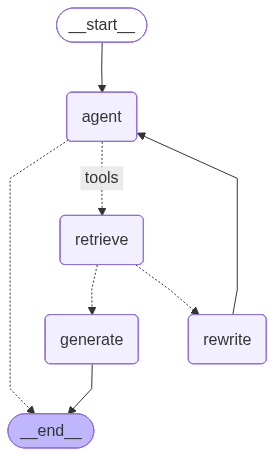

: 

In [ ]:
workflow = StateGraph(AgentState)

workflow.add_node("agent", agent)
workflow.add_node("retrieve", ToolNode(tools))

workflow.add_node("rewrite", rewrite_query)
workflow.add_node("generate", generate_answer)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", tools_condition, {"tools": "retrieve", END: END})
workflow.add_conditional_edges("retrieve", grade_documents)
workflow.add_edge("rewrite", "agent")
workflow.add_edge("generate", END)

graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

gr

In [ ]:
graph.invoke({"messages": [HumanMessage(content="What is LangGraph?")]})


---Called Agent---
---Called Grade Documents---


APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `llama-3.1-8b-instant` in organization `org_01jbfwvk5bf18vhr8e8zj4yyx0` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Requested 24898, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

: 